# What LiteLLM is

## Facade & Adapter

1. Present **Single & Simple Interface** (OpenAI format I/F).
2. **Coordinate Multiple Backend** LLMs.
3. Adapt to each Backend (convert OpenAI format to their formats).

```
                ┌───────────────────┐
App A, B, C ──► │                   │ ───► OpenAI
                │ LiteLLM SDK/Proxy │ ───► Anthropic
                │                   │ ───► Bedrock
                └───────────────────┘ ...
```
Why adapter?  
Adapter is **Conversion and Connect**. LiteLLM accept single I/F format (OpenAI) and convert to backend formats.

* [LiteLLM - Getting Started](https://docs.litellm.ai/docs/)
* [LiteLLM Cookbook](https://github.com/BerriAI/litellm/tree/main/cookbook)

# Setup

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import os
import json
import operator
from datetime import datetime, timedelta, timezone
from typing import (
    List, Dict, Any, Literal, Optional, Callable, Annotated
)

import regex as re
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
import litellm
import mdformat
import trafilatura
from IPython.display import Markdown, display

## API Keys

In [3]:
path_to_openai_key:str = os.path.expanduser('~/.openai/api_key')
with open(path_to_openai_key, 'r', encoding='utf-8') as file:
    os.environ["OPENAI_API_KEY"] = file.read().strip()

path_to_tavily_key:str = os.path.expanduser('~/.tavily/api_key')
with open(path_to_tavily_key, 'r', encoding='utf-8') as file:
    os.environ["TAVILY_API_KEY"] = file.read().strip()

## Models

In [4]:
MODEL: str = "openai/gpt-4o"

---
# LiteLLM Facade - Chat/Completion

LiteLLM still uses Open AI deprecated Chat Completion API format.

* [LiteLLM API Reference - Chat Completions - POST
/chat/completions](https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create)

> Creates a model response for the given chat conversation. Learn more in the text generation, vision, and audio guides. Returns a chat completion object, or a streamed sequence of chat completion chunk objects if the request is streamed.
> 
> **Returns:** <br>
> ```
> ChatCompletion = object { id, choices, created, 5 more }: Represents a chat completion response returned by model, based on the provided input.
> ```


In [5]:
def call_llm(
    messages: List[Dict[str, Any]],
    tools: Optional[List[Dict[str, Any]]] = None,
    stream: bool = False,
    model=MODEL,
):
    try:
        # responses is generator
        response = litellm.completion(
            model=model,
            messages=messages,
            tools=tools,
            stream=stream
        )
        return response
    except litellm.AuthenticationError as e:
        raise RuntimeError(f"Authentication failed: {e}") from e
    except litellm.RateLimitError as e:
        raise RuntimeError(f"Rate limited: {e}") from e
    except litellm.APIError as e:
        raise RuntimeError(f"API error: {e}") from e

## Batch

In constrat to **streaming**, send a one-off request to get one-off reply.

In [6]:
response: Dict[str, Any] = call_llm(messages=[{
    "role": "user",
    "content": "Hello, how are you?"
}])
print(json.dumps(response.model_dump(), indent=4, default=str))
del response

{
    "id": "chatcmpl-DM92pB6Ri0SulImaNdZv14Z4Ch2j3",
    "created": 1774170355,
    "model": "gpt-4o-2024-08-06",
    "object": "chat.completion",
    "system_fingerprint": "fp_e6c36a96dd",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "message": {
                "content": "Hello! I'm here and ready to help. How can I assist you today?",
                "role": "assistant",
                "tool_calls": null,
                "function_call": null,
                "provider_specific_fields": {
                    "refusal": null
                },
                "annotations": []
            },
            "provider_specific_fields": {}
        }
    ],
    "usage": {
        "completion_tokens": 16,
        "prompt_tokens": 13,
        "total_tokens": 29,
        "completion_tokens_details": {
            "accepted_prediction_tokens": 0,
            "audio_tokens": 0,
            "reasoning_tokens": 0,
            "rejected_pred

## Streaming

In [7]:
response: Dict[str, Any] = call_llm(
    messages=[{
        "role": "user", "content": "Hello, how are you?"
    }],
    stream=True
)

# Iterate through the generator
for chunk in response:
    # Extract the content delta
    content = chunk.choices[0].delta.content
    
    if content:
        # print(..., end="", flush=True) creates the typewriter effect
        print(content, end="", flush=True)
        
print() # Print a newline when the stream finishes    
del response

Hello

!

 I'm

 just

 a

...

 I

 assist

 you

 today

?

---
# Tool Calling Protocol


## OpenAI API Specification


OpenAI defined the **Function (Tool) Calling Protocol** as in [Function calling](https://developers.openai.com/api/docs/guides/function-calling). 

  1. LLM responds with role: "assistant" message containing tool_calls (with id, function.name, function.arguments)
  2. You execute the tools                                                      
  3. You send back one message per tool call with role: "tool", tool_call_id matching the original id, and content containing the result as a string

There are six stages in the Protocol.

1. Tool Definition by Application and Declaration to LLM at Prompt Message
> When we make an API request to the model with a prompt, we can include a list of tools the model could consider using.

2. Tool Call Decision by LLM  (**Reasoing** and **Decisoning**)
> tool call refers to a special kind of decision response from LLM to call one of the tools to execute the prompt given.
   
3. Tool Execution by Application
4. Tool Output Usage by LLM
> tool call output refers to the response a tool generates using the input from a model’s tool call. We send **all of the tool definition, the original prompt, the model’s tool call, and the tool call output back** to LLM to finally receive a text response.

5. LLM completes the prompt

### Tool Calling Workflow

```
1. Application to LLM
   │ Define and Declare Tools in the prompt
   ▼
2. LLM
   │ Reason/Decide Tool Calls
   ▼
3. Application/Orchestration
   │ Tool Executions
   ▼
4. LLM Receives Tool Outputs
   │ Use Tool Outputs
   ▼
5. LLM Complete the prompt
```

<img src="../image/tool_call_flow.png" align="left" width=500/>



## LiteLLM 

Use LiteLLM as the wrapper for OpenAI Specification for Function calling.

* [LiteLLM - Function Calling](https://docs.litellm.ai/docs/completion/function_call)

1. litellm.completion() with tools set to get_current_weather
2. Parse the Model Response and Execute Functions
3. Second litellm.completion() call

## Tool Definition

* [Defining Functions (Tools)](https://developers.openai.com/api/docs/guides/function-calling#defining-functions)

First, you define a tool based on the OpenAI definition. This is what LiteLLM accepts as well.

| Field       | Description                                          |
|-------------|------------------------------------------------------|
| type        | This should always be function                       |
| name        | The function’s name (e.g. get_weather)               |
| description | Details on when and how to use the function          |
| parameters  | JSON schema defining the function’s input arguments  |
| strict      | Whether to enforce strict mode for the function call |


### Tool Definition Format

The format of a tool definition:

```
tool_definition := {
  "type": "function",
  "function": {
     "name": "...",
     "description": "...",
     "parameters": { JSON schema }   # <--- Pydantic can generate
  }
}
```

**Example:**
```
{
  "type": "function",
  "name": "get_weather",
  "description": "Retrieves current weather for the given location.",
  "parameters": {
    "type": "object",
    "properties": {
      "location": {
        "type": "string",
        "description": "City and country e.g. Bogotá, Colombia"
      },
      "units": {
        "type": "string",
        "enum": ["celsius", "fahrenheit"],
        "description": "Units the temperature will be returned in."
      }
    },
    "required": ["location", "units"],
    "additionalProperties": false
  },
  "strict": true
}
```

### Namespace

* [Defining namespace](https://developers.openai.com/api/docs/guides/function-calling#defining-namespaces)

> Namespaces help organize similar tools and are especially useful when the model must choose between tools that serve different systems or purposes, such as one search tool for your CRM and another for your support ticketing system

```
{
  "type": "namespace",
  "name": "crm",
  "description": "CRM tools for customer lookup and order management.",
  "tools": [
      tool_definition+
 ]
}
```

### Tool Parameter JSON Schema

[Pydantic JSON Schema](https://docs.pydantic.dev/latest/concepts/json_schema/) to generate the JSON Schema for the Tool Definition. 

For the Tool Definition for the [Tavilty Search](https://docs.tavily.com/sdk/python/reference#tavily-search):


#### Tool 

In [8]:
# Function for the Search Tool
search_tool: Callable = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
if not hasattr(search_tool, "tool_name"):
    search_tool.name = "search_tool"

name_to_tool: Dict[str, Callable] = {
    # search_tool.name: search_tool.search
    search_tool.name: search_tool.search
}

#### Tool Parameters

Use Pydantic to generate the JSON Schema for the parameters.

In [9]:
# Parameters for the Search Tool
class SearchToolParameters(BaseModel):
    """
    Search the web for current events, news, or deep research.
    """
    query: str = Field(description="The search query to look up")
    
    topic: Literal["general", "news", "finance"] = Field(
        default="general",
        description="Category of search. Use 'news' for current events/politics, 'finance' for market data."
    )
    
    search_depth: Literal["basic", "advanced"] = Field(
        default="basic",
        description="Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context."
    )
    
    time_range: Optional[Literal["day", "week", "month", "year"]] = Field(
        default=None,
        description="Filter results by publication date. Especially useful with topic='news'."
    )
    
    max_results: int = Field(
        default=5, ge=1, le=10,
        description="Number of search results to return."
    )

In [10]:
search_tool_parameters: Dict[str, Any] = SearchToolParameters.model_json_schema()
print(json.dumps(search_tool_parameters, indent=2, default=str))

{
  "description": "Search the web for current events, news, or deep research.",
  "properties": {
    "query": {
      "description": "The search query to look up",
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "search_depth": {
      "default": "basic",
      "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    },
    "time_range": {
      "anyOf": [
        {
          "enum": [
            "day",
            "week",
            "month",
            "year"
          ],
          "type": "string"
        },
        {
       

#### Tool Description

In [11]:
search_tool_description: str = SearchToolParameters.__doc__.strip()
print(search_tool_description)

Search the web for current events, news, or deep research.


### Tool Definition of the Tabiliy Web Search

In [12]:
search_tool_definition = {
    "type": "function",
    "function": {
        "name": search_tool.name,
        "description": search_tool_description,
        "parameters": search_tool_parameters
    }
}
print(json.dumps(search_tool_definition, indent=2, default=str))

{
  "type": "function",
  "function": {
    "name": "search_tool",
    "description": "Search the web for current events, news, or deep research.",
    "parameters": {
      "description": "Search the web for current events, news, or deep research.",
      "properties": {
        "query": {
          "description": "The search query to look up",
          "title": "Query",
          "type": "string"
        },
        "topic": {
          "default": "general",
          "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
          "enum": [
            "general",
            "news",
            "finance"
          ],
          "title": "Topic",
          "type": "string"
        },
        "search_depth": {
          "default": "basic",
          "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
          "enum": [
            "basic",
            "advanced"
          ],
         

## Tool Declaration

You declare the **tool definitions** to the LLM.

```
tools = [
    {
      "type": "function",
      "function": {
        "name": "SearchTool",
        "description": "...",
        "parameters": { JSON Schema }
      }
    },
    ...
]
```

* [OpenAI Create chat completion API](https://developers.openai.com/api/reference/python/resources/chat/subresources/completions/methods/create/#:~:text=Streaming-,Functions,-Logprobs) or [vLLM OpenAI Chat Completion Client With Tools](https://docs.vllm.ai/en/v0.7.2/getting_started/examples/openai_chat_completion_client_with_tools.html)

> tools: Optional[Iterable[ChatCompletionToolUnionParam]]<br>
> A list of tools the model may call. You can provide either [custom tools](https://platform.openai.com/docs/guides/function-calling#custom-tools) or [function tools](https://platform.openai.com/docs/guides/function-calling).

```
completion = client.chat.completions.create(
  model="VAR_chat_model_id",
  messages=messages,
  tools=tools,
  tool_choice="auto"
)
```

* [LiteLLM Function Calling](https://docs.litellm.ai/docs/completion/function_call)

```
response = litellm.completion(
    model=model,
    messages=messages,
    tools=tools,            # <---- Declare the LLM model the tools you can use
    tool_choice="auto"
)
```

*Example*

```
{
  "model": "gpt-4o",
  "messages": [
    {
        "role": "user",                   # <--- Beware of the "role" used
        "content": "Weather in Tokyo?"
    }
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "get_weather",
        "parameters": {
          "type": "object",
          "properties": {
            "location": {"type": "string"}
          }
        }
      }
    }
  ]
}
```

### Tool Declartion for the Search

In [13]:
tool_declarations: List[Dict[str, Any]] = [
    search_tool_definition
]

### Messages to LLM

Build the the messages to LLM, which is prompt.

In [14]:
messages_prompt: List[Dict[str, str]] = [
    {
        "role": "system", 
        "content": """
You are a helpful assistant. Use tools when needed. 
Verify the relevance of retrieved results before using them, and apply an intelligent 
intent filter so you keep only the news items that align with the user's inquiry. 
Only report items that are relevant to the user request and supported by the tool output.
If the search results are noisy or insufficient, say that and do not infer missing facts.
"""
    },
    {
        "role": "user",      # <--- Beware of the "role" used
        "content": "What are the top news headlines in AI from the last week?"
    }
]

### LLM Call


In [15]:
response_to_prompt: Dict[str, Any] = call_llm(
    messages=messages_prompt,
    tools=tool_declarations
)
print(json.dumps(response_to_prompt.model_dump(), indent=4, default=str))

{
    "id": "chatcmpl-DM92rktnXloSv3M9YWNjO93chK6xh",
    "created": 1774170357,
    "model": "gpt-4o-2024-08-06",
    "object": "chat.completion",
    "system_fingerprint": "fp_302b87bc9f",
    "choices": [
        {
            "finish_reason": "tool_calls",
            "index": 0,
            "message": {
                "content": null,
                "role": "assistant",
                "tool_calls": [
                    {
                        "function": {
                            "arguments": "{\"query\":\"AI\",\"topic\":\"news\",\"time_range\":\"week\",\"max_results\":5}",
                            "name": "search_tool"
                        },
                        "id": "call_UYYwiX43XBsteKYFQ7Bwsfrl",
                        "type": "function"
                    }
                ],
                "function_call": null,
                "provider_specific_fields": {
                    "refusal": null
                },
                "annotations": []
      

## LLM Tool Calls

### Tool call handling logic

* [OpenAI - Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)

> The response output array contains an entry with the type having a value of function_call. Each entry with a call_id (used later to submit the function result), name, and JSON-encoded arguments.
> 
>``` 
> for tool_call in response.output:
>     if tool_call.type != "function_call":
>         continue
> 
>     name = tool_call.name
>     args = json.loads(tool_call.arguments)
> 
>     result = call_function(name, args)
>     input_messages.append({
>         "type": "function_call_output",
>         "call_id": tool_call.call_id,
>         "output": str(result)
>     })
>```



### Tool Calls

When the LLM decides that you should call a tool, LLM responds with ```role: "assistant"``` message containing ```tool_calls (id, function.name, function.arguments)```. There are multiple choices and each choice can have multiple tool calls.

The tool_call ```id``` is the **critical link between the application and LLM** to identify which tool call and exeuiton it handles.

```
"message": {
    "role": "assistant",                            # <--- Beware of the "role" used by LLM
    "tool_calls": [
        {
            "function": {
                "arguments": "{\"query\":\"AI news\",\"topic\":\"news\",\"search_depth\":\"basic\",\"time_range\":\"week\"}",
                "name": "search_tool"
            },
            "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",  # <--- Must be used between application and LLM
            "type": "function"
        }
    ],
}
```

In [16]:
assert "choices" in response_to_prompt.model_dump(), \
  f"Expected 'choices' in the response:\n{json.dumps(response_to_prompt, indent=2, default=str)}"

In [17]:
def extract_tool_call_messages(response: Dict[str, Any]) -> List[Dict[str, str]]:
    """Extract the tool calls requested by LLM
    Args:
        response: response from the LLM
    Returns: List of message for tool calls from LLM.
    """
    return [
        choice.get("message", {})
        for choice in response.model_dump().get("choices", [])
    ]

In [18]:
def in_time_window(result: Dict[str, Any], query: str, now: datetime) -> bool:
    """Return True when the result was published within the last month."""
    del query  # Reserved for query-aware time parsing later.
    published_date = result.get("published_date")
    if not published_date:
        return False
    try:
        published_at = datetime.strptime(
            published_date, "%a, %d %b %Y %H:%M:%S %Z"
        ).replace(tzinfo=timezone.utc)
    except ValueError:
        return False
    return published_at >= (now - timedelta(days=30))

def is_bad_page_type(result: Dict[str, Any]) -> bool:
    """Return True for page types that are poor RAG evidence for this tutorial."""
    negative_markers = ('/event/', 'event', 'retreat', 'viewership', '/journalism/')
    title = str(result.get("title", "")).lower()
    url = str(result.get("url", "")).lower()
    return any(marker in title or marker in url for marker in negative_markers)

def keep_result(query: str, result: Dict[str, Any], now: datetime) -> bool:
    """Return True when a Tavily result is usable for the final answer."""
    if not in_time_window(result, query, now):
        return False
    if is_bad_page_type(result):
        return False
    if float(result.get("score", 0.0)) < 0.85:
        return False
    return True

def filter_search_results(results: List[Dict[str, Any]], query: str) -> List[Dict[str, Any]]:
    """Keep only search hits that are recent, relevant, and usable."""
    now = datetime.now(timezone.utc)
    return [result for result in results if keep_result(query, result, now)]

def format_search_result(result: Dict[str, Any]) -> str:
    """Serialize one Tavily result as JSON for the tool response."""
    payload = {
        "title": result.get("title", ""),
        "url": result.get("url", ""),
        "content": result.get("content", ""),
        "published_date": result.get("published_date"),
    }
    return json.dumps(payload, ensure_ascii=False)

def execute_tool_calls(messages: List[Dict[str, str]]) -> List[Dict[str, str]]:
    """Execute tool calls requested by LLM.
    Args:
        messages: Messages for tool calls requests from LLM.
    Returns:
        messages_tool_outputs: 
            Tool output messages built from tool executions in the LiteLLM format.
            The messages are part of those to be sent back to LLM.
            The format for LiteLLM is [{
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            }]
    """
    _messages_tool_outputs: List[Any] = []
    for _message in messages:
        for tool_call in _message.get('tool_calls', {}):
            if tool_call.get('type', '') != 'function':
                continue;

            func_name: str = tool_call['function']['name']
            func_args: Dict[str, str] = json.loads(tool_call['function']['arguments'])
            execution: Any = name_to_tool[func_name](**func_args)
            results = execution.get('results', [])
            if func_name == 'search_tool':
                results = filter_search_results(results=results, query=func_args.get('query', ''))
            if not results:
                content = json.dumps({
                    'query': func_args.get('query', ''),
                    'results': [],
                    'note': 'No clearly relevant search results were found. Ask for a narrower query or different source.'
                }, ensure_ascii=False)
            else:
                content = json.dumps({
                    'query': func_args.get('query', ''),
                    'results': [
                        json.loads(format_search_result(r)) for r in results
                    ]
                }, ensure_ascii=False)
            _messages_tool_outputs.append({
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            })

    return _messages_tool_outputs

In [19]:
import markdown
from html.parser import HTMLParser

class _StripHTML(HTMLParser):
    """Extract plain text from HTML, used as fallback in render_content."""
    def __init__(self):
        super().__init__()
        self._parts = []
    def handle_data(self, data):
        self._parts.append(data)
    def get_text(self) -> str:
        return ''.join(self._parts)

def render_content(content: str, url: str) -> str:
    """Return clean plain text from url for display(Markdown(...)).
    Fetches original article text via trafilatura (preferred).
    Falls back to parsing the Tavily markdown snippet via the markdown
    package to strip heading/formatting artifacts.
    Args:
        content: Tavily markdown snippet (fallback source).
        url:     Original article URL (preferred source).
    """
    if url:
        downloaded = trafilatura.fetch_url(url)
        fetched = trafilatura.extract(downloaded) if downloaded else None
        if fetched:
            return fetched.replace('\xa0', ' ')
    # Fallback: markdown → HTML → strip tags → plain text
    html = markdown.markdown(content)
    extractor = _StripHTML()
    extractor.feed(html)
    return extractor.get_text().replace('\xa0', ' ')


In [20]:
def show_tool_executions(outputs: List[Dict[str, Any]]) -> None:
    """Display tool execution results.
    Parses JSON tool payloads and calls render_content(content, url)
    to fetch clean article text for display.
    """
    for msg in outputs:
        payload = json.loads(msg.get('content', '{}'))
        results = payload.get('results', [])
        if not results:
            note = payload.get('note', 'No tool results to display.')
            display(Markdown(note))
            continue
        for result in results:
            source = result.get('title', '')
            url = result.get('url', '')
            article_content = result.get('content', '')
            published_date = result.get('published_date')
            clean = render_content(content=article_content, url=url)
            header = f'**{source}**'
            if published_date:
                header += f'\n\nPublished: {published_date}'
            display(Markdown(f'{header}\n\n{clean}'))
            display(Markdown('---'))


In [21]:
messages_tool_calls: List[Dict[str, Any]] = extract_tool_call_messages(response=response_to_prompt)
messages_tool_outputs: List[Dict[str, Any]] = execute_tool_calls(messages=messages_tool_calls)

In [22]:
show_tool_executions(outputs=messages_tool_outputs)

**The Smartest Minds in AI Just Learned the World’s Most Valuable F-Word - WSJ**

Published: Sat, 21 Mar 2026 01:00:00 GMT

https://www.wsj.com/tech/ai/openai-anthropic-claude-code-apple-steve-jobs-4cdc28d2. # The Smartest Minds in AI Just Learned the World’s Most Valuable F-Word. Copyright ©2026 Dow Jones & Company, Inc. All Rights Reserved. The AI company will combine ChatGPT, Codex app and browser in an effort to focus and streamline its resources. Find insight on artificial intelligence displacing software, Tesla, Anthropic and more in the latest Market Talks covering Technology, Media and Telecom. ### Why Even Smart People Believe AI Is Really Thinking. ### Apple Is Way Behind in AI—and Still Making a Fortune From It. The iPhone maker’s AI revenue is set to top $1 billion this year, reassuring investors who are wary of the sky-high spending of its rivals. Plus, employers are tracking the use of AI tokens and Uber is investing in Rivian robotaxis. The AI sprint is hurtling toward a world where anyone can build personal concierges to do everything from executive presentations to March Madness brackets. Best Term Life Insurance Companies of 2026. Best Pet Insurance Companies of 2026.

---

### Entire History Back to LLM

The entire context (conversation history) must be sent back to LLM to continue.

1. Initial prompt messages.
2. Tool call messages from LLM.
3. Tool execution message from tool call executions.

LLM cannot keep the session memmory forever. It is the responsibiliyt of the application to manage the state memory.


* [Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)
> ```
> input_messages.append({                     # <--- Appending the ouput to the first message sent to LLM
>     "type": "function_call_output",
>     "call_id": tool_call.call_id,           # <--- Must use the same tool_call ID given from LLM for the tool call.
>     "output": str(result)
> })
> ```

* [Formatting Result](https://developers.openai.com/api/docs/guides/function-calling#formatting-results)

> The result you pass in the function_call_output message should typically be a string, where the format is up to you (JSON, error codes, plain text, etc.). The model will interpret that string as needed.
> 
> For functions that return images or files, you can pass an array of image or file objects instead of a string.
> 
> If your function has no return value (e.g. send_email), simply return a string that indicates success or failure. (e.g. "success")

* [Incorporating results into response](https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response)

> After appending the results to your input, you can send them back to the model to get a final response.
> ```
> response = client.responses.create(
>     model="gpt-4.1",
>     input=input_messages,
>     tools=tools,
> )
> ```

### LiteLLM Format

* [Step 3 - Second litellm.completion() call](https://docs.litellm.ai/docs/completion/function_call#step-3---second-litellmcompletion-call)

> ```
> if tool_calls:
>     messages.append(response_message)  # Extend conversation with assistant's reply
>     for tool_call in tool_calls:
>         print(f"\nExecuting tool call\n{tool_call}")
>         function_name = tool_call.function.name
>         function_to_call = available_functions[function_name]
>         function_args = json.loads(tool_call.function.arguments)
>         function_response = function_to_call(
>             location=function_args.get("location"),
>             unit=function_args.get("unit"),
>         )
> 
>         # Extend conversation with function response
>         messages.append(                        # <--- Appending to the original messages
>             {
>                 "role": "tool",                 # <--- Beware of the "role" = "tool" is used.
>                 "name": function_name,
>                 "content": function_response,
>                 "tool_call_id": tool_call.id,   # <--- Must use the same tool_call ID given from LLM
>             }
>         )
>```


In [23]:
# Full conversation history required by OpenAI protocol:
# prompt (system+user) → assistant (with tool_calls) → tool results
messages_tools_called: List[Dict[str, Any]] = messages_prompt + messages_tool_calls + messages_tool_outputs
response_to_tools_called: Dict[str, Any] = call_llm(messages=messages_tools_called)

In [24]:
print(json.dumps(response_to_tools_called.model_dump(), indent=2, default=str))

{
  "id": "chatcmpl-DM92vkvqPPIUHaS3SRWIYzytMsdQk",
  "created": 1774170361,
  "model": "gpt-4o-2024-08-06",
  "object": "chat.completion",
  "system_fingerprint": "fp_3e502a9bb4",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "The search results returned limited relevant information and seem somewhat noisy. I recommend checking a news outlet or platform dedicated to technology updates for the latest AI news headlines from the last week.",
        "role": "assistant",
        "tool_calls": null,
        "function_call": null,
        "provider_specific_fields": {
          "refusal": null
        },
        "annotations": []
      },
      "provider_specific_fields": {}
    }
  ],
  "usage": {
    "completion_tokens": 35,
    "prompt_tokens": 596,
    "total_tokens": 631,
    "completion_tokens_details": {
      "accepted_prediction_tokens": 0,
      "audio_tokens": 0,
      "reasoning_tokens": 0,
      "rejected_prediction_

In [25]:
del messages_tool_calls, messages_tool_outputs, messages_tools_called, response_to_tools_called

---

## LangGraph Workflow

NOTE: **messages** in the LangGraph State corresponds with the entire message history with the Tool Call messages.

LangGraph accumuates the messages exchanged and genreated in the State.

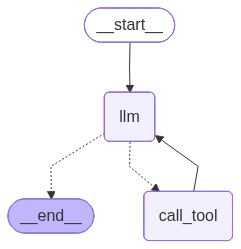

In [26]:
# LangGrph State Definition (Pydantic)
class AgentState(BaseModel):
    messages: Annotated[List[dict], operator.add] = Field(default_factory=list)

# Lang Graph Nodes
def call_model(state: AgentState):
    """Node to call the LLM
    """
    # Sends entire historical messages? Is it correct?
    response = call_llm(
        messages=state.messages, 
        tools=tool_declarations
    )
    return {"messages": [response.choices[0].message.model_dump()]}

def call_tool(state: AgentState):
    """Node to call a tool
    """
    last_msg = state.messages[-1]
    message_tool_outputs: List[Dict[str, Any]] = execute_tool_calls(messages=[last_msg])
    return {"messages": message_tool_outputs}
    
# 6. ROUTER & GRAPH
def router(state: AgentState) -> Literal["call_tool", "__end__"]:
    last_msg = state.messages[-1]
    return "call_tool" if last_msg.get("tool_calls") else "__end__"

builder = StateGraph(AgentState)
builder.add_node("llm", call_model)
builder.add_node("call_tool", call_tool)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", router)
builder.add_edge("call_tool", "llm")
app = builder.compile()

app

In [27]:
# 7. EXECUTION
inputs = {
    'messages': [
        {
            'role': 'user',     # <--- Beware of the 'role' used
            'content': 'What are the top news headlines in AI from the last week?'
        }
    ]
}

for event in app.stream(inputs, stream_mode='values'):
    last_msg = event['messages'][-1]

    role = last_msg.get('role', 'assistant').upper() if isinstance(last_msg, dict) else last_msg.role.upper()
    tool_calls = last_msg.get('tool_calls') if isinstance(last_msg, dict) else getattr(last_msg, 'tool_calls', None)
    content = last_msg.get('content') if isinstance(last_msg, dict) else getattr(last_msg, 'content', '')

    if tool_calls:
        first_call = tool_calls[0]
        args_str = first_call['function']['arguments'] if isinstance(first_call, dict) else first_call.function.arguments
        params = json.loads(args_str)
        print(f'\n--- {role} (Calling Search with params: {params}) ---')

    elif role == 'TOOL' and content:
        print(f'\n--- {role} ---')
        show_tool_executions(outputs=[last_msg])

    else:
        print(f'\n--- {role} ---')
        if content:
            print(content)
            display(Markdown(content))
        else:
            print('Processing...')



--- USER ---
What are the top news headlines in AI from the last week?


What are the top news headlines in AI from the last week?


--- ASSISTANT (Calling Search with params: {'query': 'AI news', 'topic': 'news', 'search_depth': 'basic', 'time_range': 'week', 'max_results': 5}) ---



--- TOOL ---


**Wall-climbing robots swarm US Navy warships - Fox News**

Published: Thu, 19 Mar 2026 18:48:56 GMT

Welcome to Fox News’ Artificial Intelligence newsletter with the latest AI technology advancements.
IN TODAY’S NEWSLETTER:
- WATCH: Wall-climbing robot swarms crawl US Navy warships as China's fleet surges
- OPINION: AI comes with a hefty charge, and you are the one who gets stuck with the bill
- Dell workforce shrinks 10% for third consecutive year
TECH AT SEA: WATCH: Wall-climbing robot swarms crawl US Navy warships as China's fleet surges – Fox News Digital reports on a new development in naval technology, featuring wall-climbing robot swarms that are crawling on U.S. Navy warships. This advancement comes at a critical time in defense politics as China's naval fleet continues to surge in size and capability.
WALLET SHOCK: OPINION: AI comes with a hefty charge, and you are the one who gets stuck with the bill – In this opinion piece, the author discusses the economic implications of the growing artificial intelligence industry. The article argues that the hefty costs associated with AI development and its massive energy infrastructure will ultimately be passed down, leaving everyday consumers to foot the bill.
COST CRUNCH: Dell workforce shrinks 10% for third consecutive year – Fox Business reports that Dell's workforce has shrunk by ten percent. This marks the third consecutive year of workforce reductions for the major technology company amid shifting economic conditions and corporate restructuring.
AIMING HIGH: FULL AUTONOMY: AI pilot technology advances towards military capability – Merlin CEO Matt George details how the company is using artificial intelligence to enable military and commercial aircraft to operate fully autonomously on Fox Business' ‘The Claman Countdown.’
SHOULD I BUY?: Homebuyers, sellers turning to AI chatbots for advice – Prairie Operating Co.'s Lou Basenese and real estate broker Kirsten Jordan discuss how artificial intelligence is impacting homebuyers and sellers on 'Fox Business In Depth.'
DISRUPTION IS HERE: Charles Payne: AI disruption is here – Fox Business host Charles Payne discusses the economic impact of the rise in artificial intelligence on 'Making Money.'
BUILDING HER BUSINESS: How Angie Hicks turned Angi into a home services giant and AI player – Angi co-founder Angie Hicks discusses entrepreneurship, company growth and how she built out her business on 'Mornings with Maria.'
Subscribe now to get the Fox News Artificial Intelligence Newsletter in your inbox.
FOLLOW FOX NEWS ON SOCIAL MEDIA
Facebook
Instagram
YouTube
X
LinkedIn
SIGN UP FOR OUR OTHER NEWSLETTERS
Fox News First
Fox News Opinion
Fox News Lifestyle
Fox News Health
DOWNLOAD OUR APPS
Fox News
Fox Business
Fox Weather
Fox Sports
Tubi
WATCH FOX NEWS ONLINE
STREAM FOX NATION
Stay up to date on the latest AI technology advancements, and learn about the challenges and opportunities AI presents now and for the future with Fox News here.

...

---

**AI Will Soon Run An Entire Ad Campaign - TV News Check**

Published: Mon, 16 Mar 2026 19:27:17 GMT

Home » AI Will Soon Run An Entire Ad Campaign. # AI Will Soon Run An Entire Ad Campaign. A new agentic AI platform launched last week to help brands and agencies plan and activate media campaigns using what the company calls a “neuro-contextual intelligence” technology attempt to identify a consumer’s emotions at the time that person considers a purchase. ### NewsTechForum 2025 lightning round: AI tools target workflow flexibility, first-party data & new revenue. Explore Top Media Industry Job Openings. Current job openings in the media industry, including roles in news production, digital media, management, and sales. ### NewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. Watch videoNewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. ### NewsTECHForum Video: How Broadcasters Are Operationalizing A ‘News Everywhere’ Strategy. ### NewsTECHForum Video: Media Leaders Are Finally Breaking Up With Algorithms. ### NewsTECHForum Video: AI & The New Operational Reality Of The Newsroom. ### Programming Everywhere: AI & Content’s Next Generation.

---


--- ASSISTANT ---
Here are some of the top news headlines in AI from the last week:

1. **Wall-climbing robots swarm US Navy warships** - This article from Fox News discusses new technology advancements where wall-climbing robots are used on U.S. Navy warships, highlighting AI-based autonomous pilot technology for military use and the increasing influence of AI chatbots on homebuyers and sellers [Read more](https://www.foxnews.com/tech/ai-newsletter-wall-climbing-robots-swarm-us-navy-warships).

2. **Quicken Is Producing 100 Pieces of Content Every Few Weeks Using AI** - According to ADWEEK, Quicken is utilizing AI to generate large volumes of content as part of their updated strategy focused on using large language models for consumer engagement [Read more](https://www.adweek.com/media/quicken-is-producing-100-pieces-of-content-every-few-weeks-using-ai/).

3. **AI Will Soon Run An Entire Ad Campaign** - A report by TV News Check covers a new AI platform designed to assist brands and 

Here are some of the top news headlines in AI from the last week:

1. **Wall-climbing robots swarm US Navy warships** - This article from Fox News discusses new technology advancements where wall-climbing robots are used on U.S. Navy warships, highlighting AI-based autonomous pilot technology for military use and the increasing influence of AI chatbots on homebuyers and sellers [Read more](https://www.foxnews.com/tech/ai-newsletter-wall-climbing-robots-swarm-us-navy-warships).

2. **Quicken Is Producing 100 Pieces of Content Every Few Weeks Using AI** - According to ADWEEK, Quicken is utilizing AI to generate large volumes of content as part of their updated strategy focused on using large language models for consumer engagement [Read more](https://www.adweek.com/media/quicken-is-producing-100-pieces-of-content-every-few-weeks-using-ai/).

3. **AI Will Soon Run An Entire Ad Campaign** - A report by TV News Check covers a new AI platform designed to assist brands and agencies in planning and executing media campaigns using neuro-contextual intelligence to understand consumers' emotions during purchasing decisions [Read more](https://tvnewscheck.com/ai/article/ai-will-soon-run-an-entire-ad-campaign/).